In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

print("\n==============================")
print("07B CONNECTIVITY HEATMAP")
print("==============================\n")


# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

print("STEP 1: Loading CSV...")

df = pd.read_csv( r"C:\Users\JHS\Documents\Python\project_folder_4B\results.csv")

print("✓ CSV loaded successfully")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print("\nColumns found:")
print(df.columns.tolist())





07B CONNECTIVITY HEATMAP

STEP 1: Loading CSV...
✓ CSV loaded successfully
  Rows: 35,282
  Columns: 7

Columns found:
['source_id', 'source_type', 'source_instance', 'target_id', 'target_type', 'target_instance', 'synapses']



07B CONNECTIVITY HEATMAP

STEP 1: Loading CSV...
✓ CSV loaded successfully
  Rows: 35,282
  Columns: 7

Columns found:
['source_id', 'source_type', 'source_instance', 'target_id', 'target_type', 'target_instance', 'synapses']

STEP 2: Checking required columns...
✓ All required columns found

STEP 3: Cleaning data...
✓ Removed 1,614 rows with missing information
  Remaining connections: 33,668
  Unique 07B source neurons: 91
  Unique 07B source types: 42
  Unique downstream target types: 2806

Filtering connections with fewer than 10 synapses...
✓ Removed 29,718 weak connections
  Remaining connections: 3,950
  Remaining source neurons: 91

STEP 4: Collapsing individual targets into target types...
✓ Target neurons collapsed by type
  Resulting connections: 2,490

STEP 5: Building neuron × target-type matrix...
✓ Connectivity matrix created
  Source neurons: 91
  Target types: 965
  Total synapses represented: 101,999

STEP 6: Normalizing each neuron's output...
✓ Normalization comple

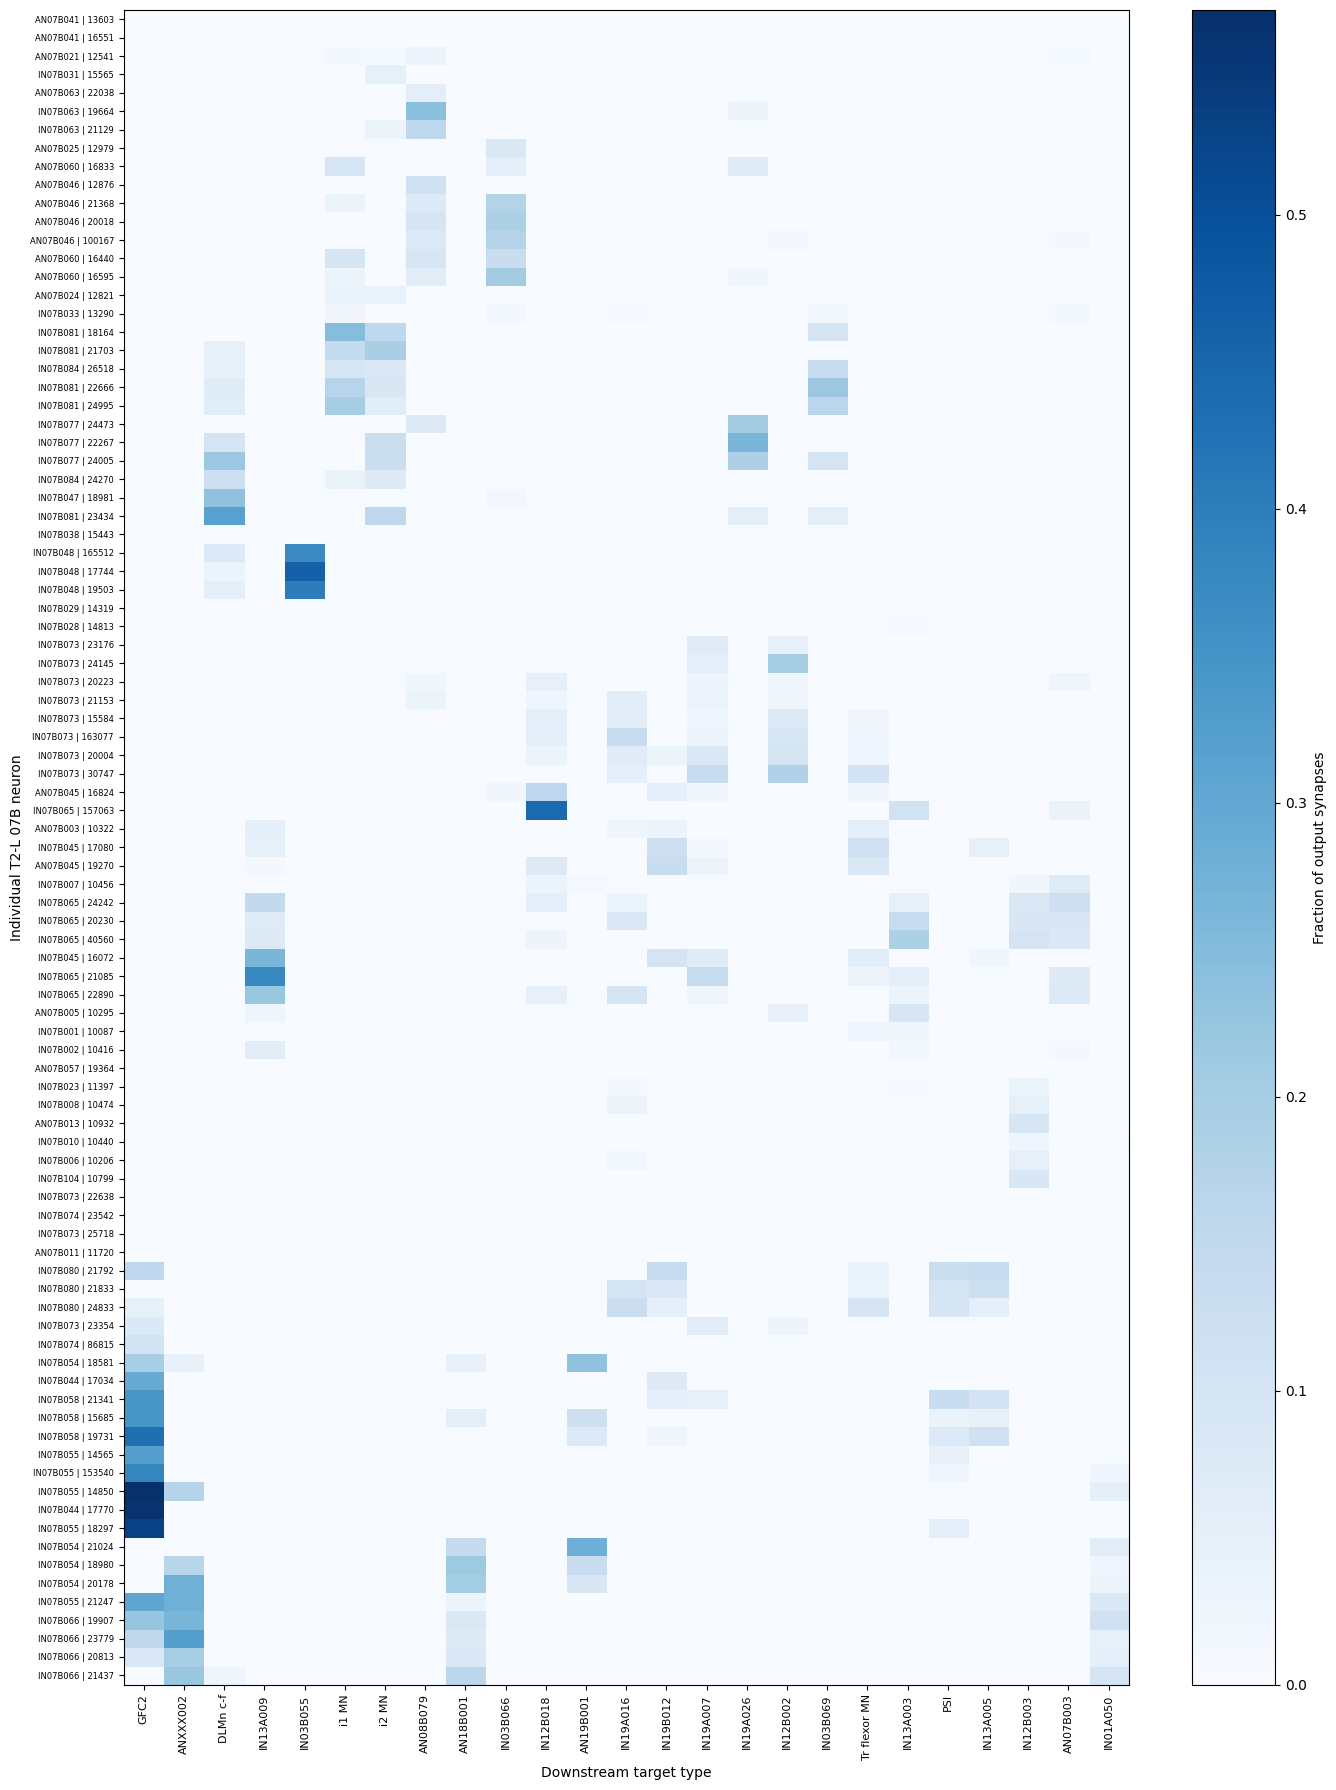

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

print("\n==============================")
print("07B CONNECTIVITY HEATMAP")
print("==============================\n")


# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

print("STEP 1: Loading CSV...")

df = pd.read_csv( r"C:\Users\JHS\Documents\Python\project_folder_4B\results.csv")

print("✓ CSV loaded successfully")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print("\nColumns found:")
print(df.columns.tolist())


# ============================================================
# STEP 2 — CHECK REQUIRED COLUMNS
# ============================================================

print("\nSTEP 2: Checking required columns...")

required_columns = [
    "source_id",
    "source_type",
    "source_instance",
    "target_type",
    "synapses"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(
        f"ERROR: Missing columns: {missing}\n"
        f"Columns actually present: {df.columns.tolist()}"
    )

print("✓ All required columns found")


# ============================================================
# STEP 3 — CLEAN DATA
# ============================================================

print("\nSTEP 3: Cleaning data...")

before = len(df)

df = df.dropna(
    subset=[
        "source_id",
        "source_type",
        "target_type",
        "synapses"
    ]
)

after = len(df)

print(f"✓ Removed {before - after:,} rows with missing information")
print(f"  Remaining connections: {after:,}")

print(
    f"  Unique 07B source neurons: "
    f"{df['source_id'].nunique()}"
)

print(
    f"  Unique 07B source types: "
    f"{df['source_type'].nunique()}"
)

print(
    f"  Unique downstream target types: "
    f"{df['target_type'].nunique()}"
)


# ============================================================
# STEP 4 — COLLAPSE TARGET NEURONS INTO TARGET TYPES
# ============================================================

MIN_SYNAPSES = 10

print(f"\nFiltering connections with fewer than {MIN_SYNAPSES} synapses...")

before = len(df)

df = df[df["synapses"] >= MIN_SYNAPSES].copy()

after = len(df)

print(f"✓ Removed {before - after:,} weak connections")
print(f"  Remaining connections: {after:,}")
print(f"  Remaining source neurons: {df['source_id'].nunique()}")
print("\nSTEP 4: Collapsing individual targets into target types...")

grouped = (
    df.groupby(
        [
            "source_id",
            "source_type",
            "source_instance",
            "target_type"
        ],
        as_index=False
    )["synapses"]
    .sum()
)

print("✓ Target neurons collapsed by type")
print(f"  Resulting connections: {len(grouped):,}")


# ============================================================
# STEP 5 — BUILD CONNECTIVITY MATRIX
# ============================================================

print("\nSTEP 5: Building neuron × target-type matrix...")

matrix = grouped.pivot_table(
    index=[
        "source_id",
        "source_type",
        "source_instance"
    ],
    columns="target_type",
    values="synapses",
    aggfunc="sum",
    fill_value=0
)

print("✓ Connectivity matrix created")
print(f"  Source neurons: {matrix.shape[0]}")
print(f"  Target types: {matrix.shape[1]}")

print(
    f"  Total synapses represented: "
    f"{matrix.values.sum():,.0f}"
)


# ============================================================
# STEP 6 — NORMALIZE OUTPUT
# ============================================================

print("\nSTEP 6: Normalizing each neuron's output...")

normalized = matrix.div(
    matrix.sum(axis=1),
    axis=0
).fillna(0)

row_sums = normalized.sum(axis=1)

print("✓ Normalization complete")
print(
    f"  Row sums range from "
    f"{row_sums.min():.3f} to {row_sums.max():.3f}"
)

print("  Expected: approximately 1.000")


# ============================================================
# STEP 7 — CLUSTER NEURONS
# ============================================================

print("\nSTEP 7: Clustering neurons by downstream connectivity...")

distance = pdist(
    normalized.values,
    metric="cosine"
)

Z = linkage(
    distance,
    method="average"
)

row_order = leaves_list(Z)

clustered = normalized.iloc[row_order]

print("✓ Hierarchical clustering complete")
print(f"  Neurons clustered: {len(clustered)}")


# ============================================================
# STEP 8 — SELECT TARGETS TO DISPLAY
# ============================================================

print("\nSTEP 8: Selecting strongest downstream targets...")

NUMBER_OF_TARGETS = 25

top_targets = (
    normalized.sum(axis=0)
    .sort_values(ascending=False)
    .head(NUMBER_OF_TARGETS)
    .index
)

plot_matrix = clustered[top_targets]

print(
    f"✓ Selected top {len(top_targets)} "
    f"target types for visualization"
)

print("\nTargets being displayed:")

for i, target in enumerate(top_targets, start=1):
    print(f"  {i:2d}. {target}")


# ============================================================
# STEP 9 — MAKE HEATMAP
# ============================================================

print("\nSTEP 9: Creating heatmap...")

row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type, source_instance
    in plot_matrix.index
]

fig, ax = plt.subplots(
    figsize=(14, 18)
)

im = ax.imshow(
    plot_matrix.values,
    aspect="auto",
    cmap="Blues",
    vmin=0
)

ax.set_xticks(
    range(len(plot_matrix.columns))
)

ax.set_xticklabels(
    plot_matrix.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticks(
    range(len(plot_matrix.index))
)

ax.set_yticklabels(
    row_labels,
    fontsize=6
)

ax.set_xlabel(
    "Downstream target type"
)

ax.set_ylabel(
    "Individual T2-L 07B neuron"
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Fraction of output synapses"
)

plt.tight_layout()

print("✓ Heatmap created")


# ============================================================
# STEP 10 — SAVE FIGURES
# ============================================================

print("\nSTEP 10: Saving figures...")

plt.savefig(
    "07B_connectivity_clustered_heatmap.pdf",
    bbox_inches="tight"
)

print("✓ Saved PDF")

plt.savefig(
    "07B_connectivity_clustered_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

print("✓ Saved PNG")


# ============================================================
# FINISHED
# ============================================================

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

print(
    f"\nAnalyzed {matrix.shape[0]} "
    f"individual 07B neurons"
)

print(
    f"Across {matrix.shape[1]} "
    f"downstream target types"
)

print(
    f"Displaying top {len(top_targets)} "
    f"target types"
)

print("\nOutput files:")
print("  07B_connectivity_clustered_heatmap.pdf")
print("  07B_connectivity_clustered_heatmap.png")

print("\nOpening heatmap...\n")

plt.show()

Creating 95th-percentile capped heatmap...
95th percentile = 0.3131


C:\Users\JHS\AppData\Local\Temp\ipykernel_25968\1595398459.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved:
  07B_connectivity_fraction_95pct_heatmap.pdf
  07B_connectivity_fraction_95pct_heatmap.png


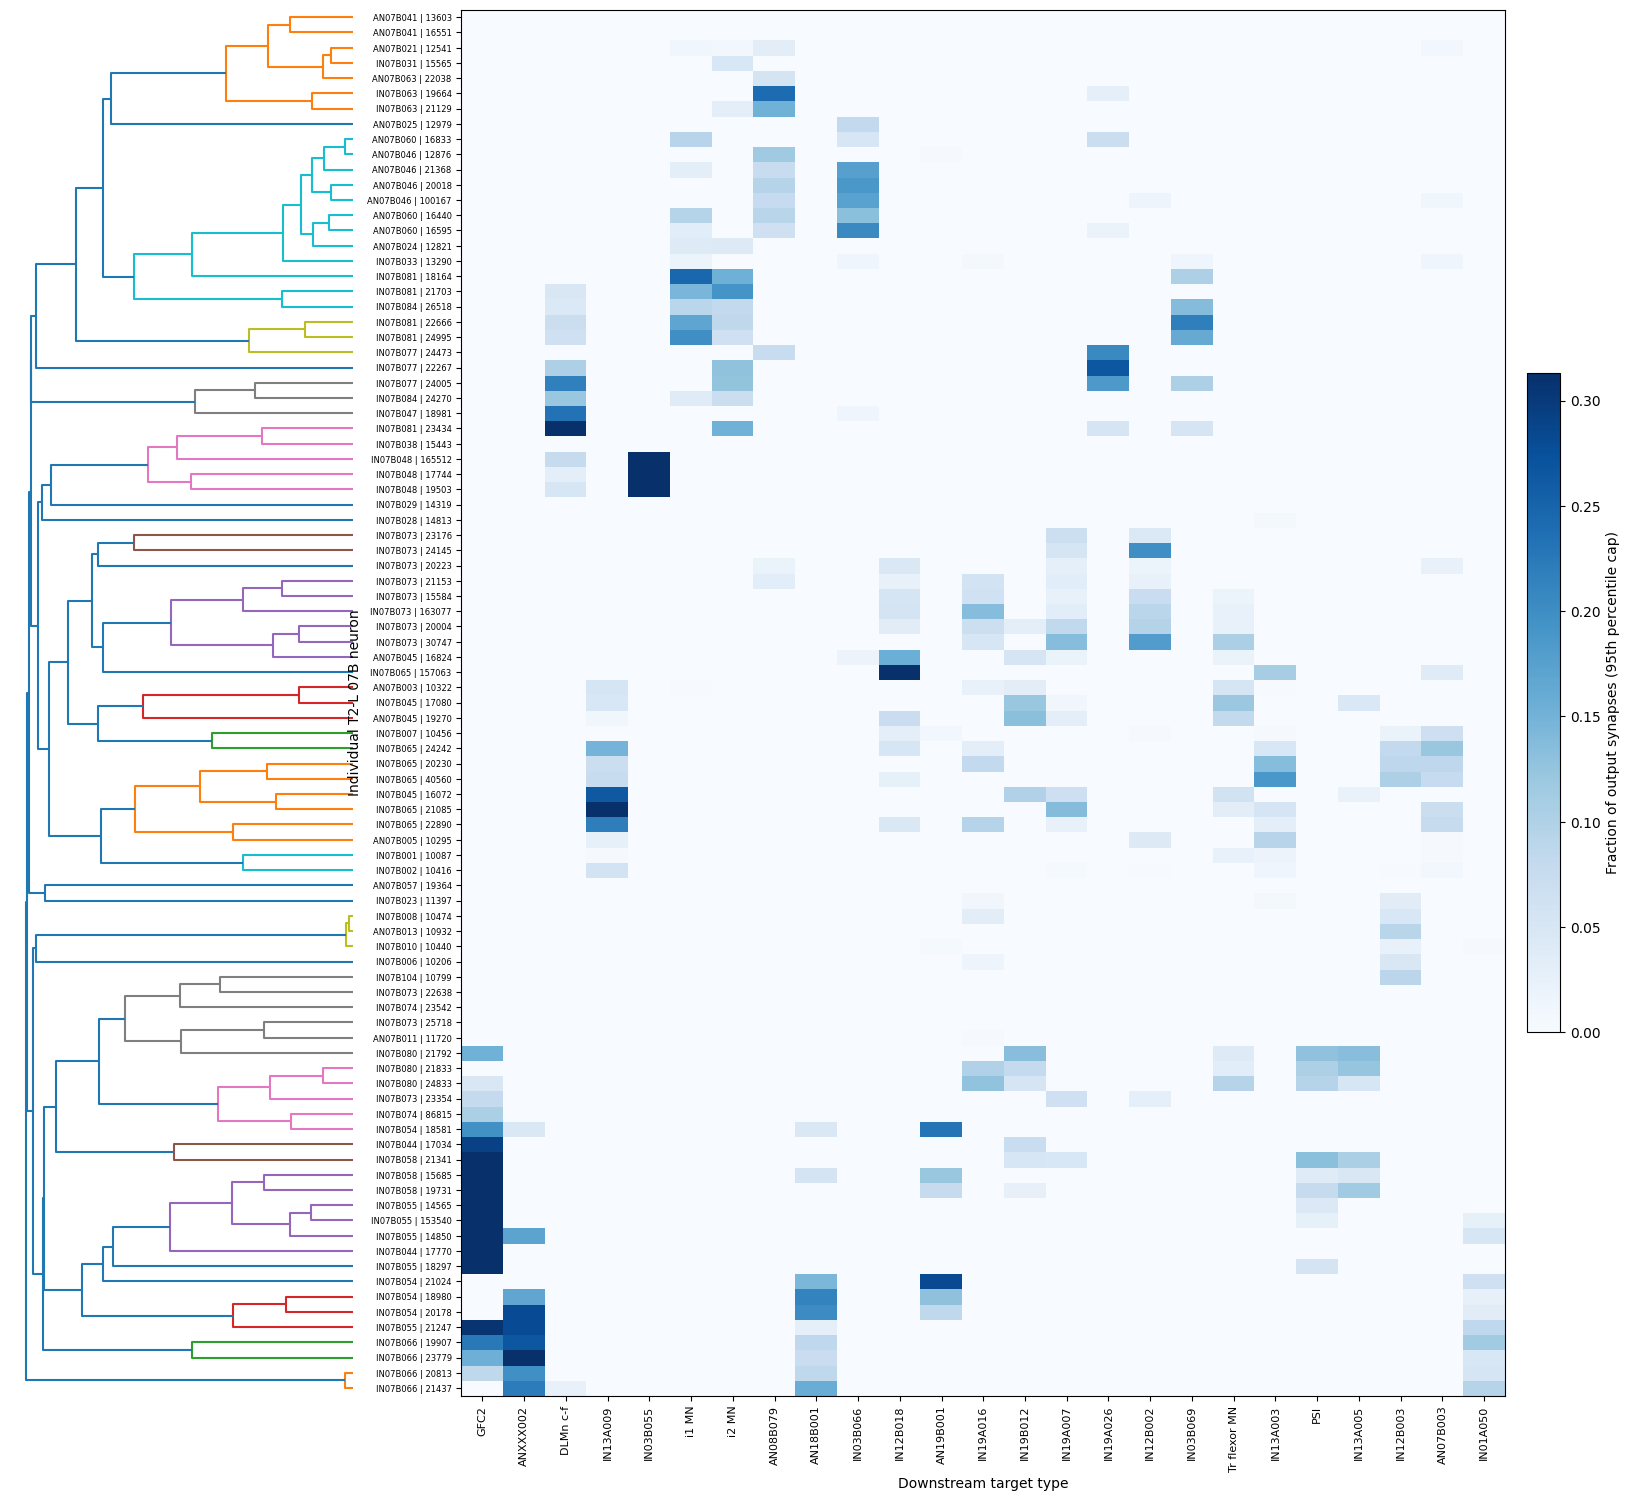

In [5]:
#fraction heatmap, instead of transforming the values, cap the color scale at something like the 95th percentile:
# import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

print("Creating 95th-percentile capped heatmap...")

# ============================================================
# CALCULATE 95TH PERCENTILE
# Only use non-zero connectivity values
# ============================================================

nonzero_values = plot_matrix.values[plot_matrix.values > 0]

vmax_95 = np.percentile(nonzero_values, 95)

print(f"95th percentile = {vmax_95:.4f}")


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(figsize=(20, 18))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[2.5, 8],
    wspace=0.15
)











# ============================================================
# DENDROGRAM
# ============================================================

ax_dendro = fig.add_subplot(gs[0])

dendro = dendrogram(
    Z,
    orientation="left",
    no_labels=True,
    ax=ax_dendro
)

ax_dendro.set_xticks([])
ax_dendro.set_yticks([])

for spine in ax_dendro.spines.values():
    spine.set_visible(False)


# ============================================================
# USE SAME ROW ORDER AS DENDROGRAM
# ============================================================

dendro_order = dendro["leaves"]

clustered = normalized.iloc[dendro_order]

plot_matrix_95 = clustered[top_targets]


# ============================================================
# ROW LABELS
# ============================================================

row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type, source_instance
    in plot_matrix_95.index
]


# ============================================================
# HEATMAP — 95% CAP
# ============================================================

ax_heatmap = fig.add_subplot(gs[1])

im = ax_heatmap.imshow(
    plot_matrix_95.values,
    cmap="Blues",
    vmin=0,
    vmax=vmax_95,
    aspect="auto",
    interpolation="nearest"
)

ax_heatmap.set_xticks(range(len(plot_matrix_95.columns)))
ax_heatmap.set_xticklabels(
    plot_matrix_95.columns,
    rotation=90,
    fontsize=8
)

ax_heatmap.set_yticks(range(len(plot_matrix_95.index)))
ax_heatmap.set_yticklabels(
    row_labels,
    fontsize=6
)

ax_heatmap.set_xlabel("Downstream target type")
ax_heatmap.set_ylabel("Individual T2-L 07B neuron")


# ============================================================
# COLOR BAR
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax_heatmap,
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Fraction of output synapses (95th percentile cap)")


# ============================================================
# SAVE WITH NEW FILENAMES
# ============================================================

plt.tight_layout()

plt.savefig(
    "07B_connectivity_fraction_95pct_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "07B_connectivity_fraction_95pct_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

print("✓ Saved:")
print("  07B_connectivity_fraction_95pct_heatmap.pdf")
print("  07B_connectivity_fraction_95pct_heatmap.png")

plt.show()

Creating two-way clustered connectivity heatmap...
  Neurons: 91
  Target types: 25
After cleanup:
  Neurons: 83
  Target types: 25
  Any NaN? False
  Any infinite values? False
  Zero rows: 0
  Zero columns: 0
  95th percentile cap: 0.3131
✓ Two-way clustered heatmap complete
✓ Saved:
  07B_connectivity_two_way_clustered_95pct.pdf
  07B_connectivity_two_way_clustered_95pct.png


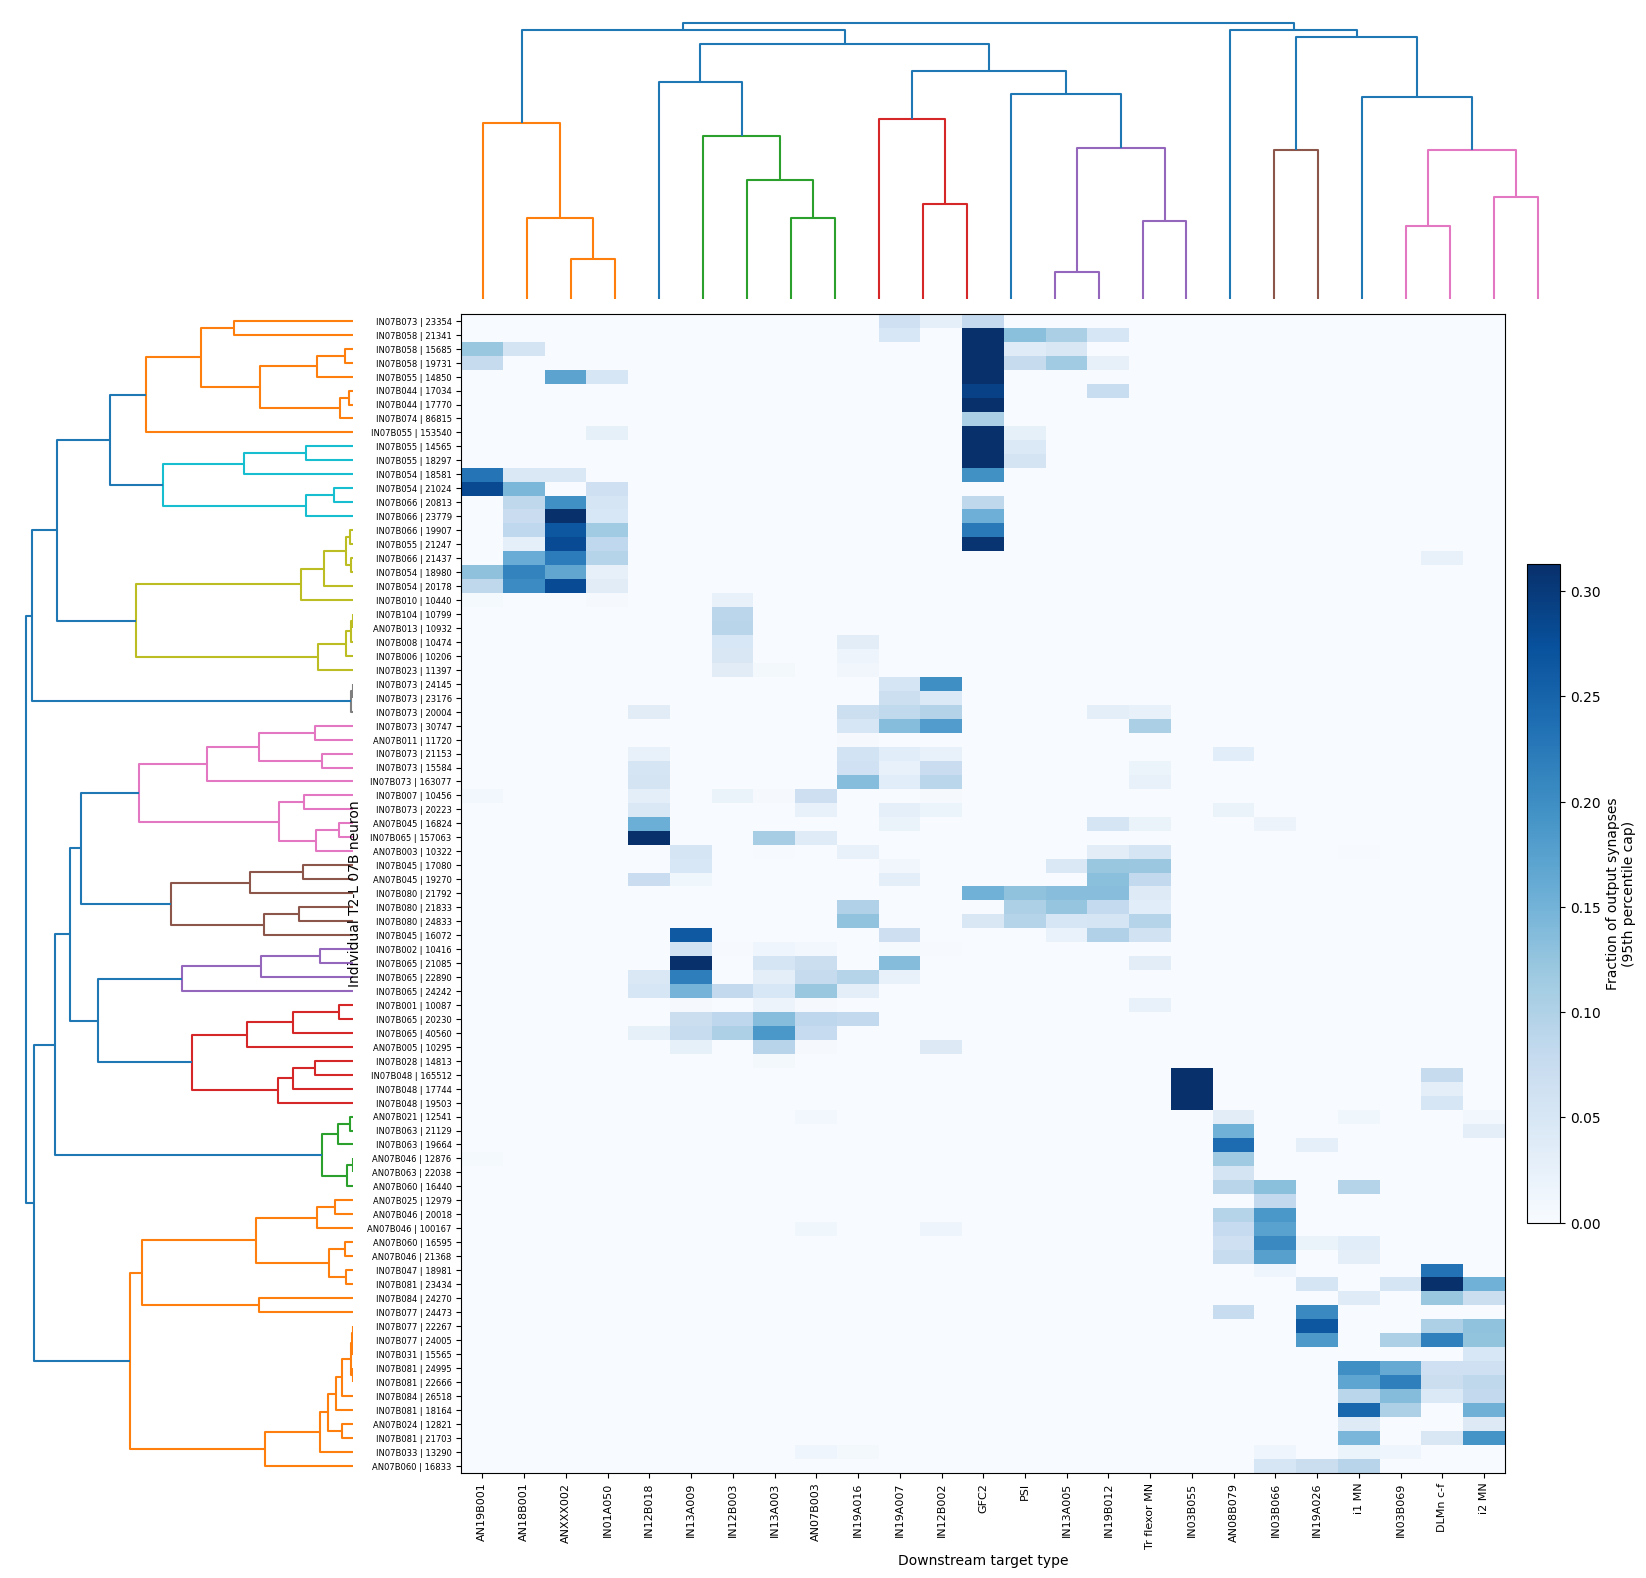

In [8]:
#code to make roatio plot cut at 95% for strong cotnrast and with targets clsutered as (columns) as well as the 7B neurons (rows)
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

print("Creating two-way clustered connectivity heatmap...")




# ============================================================
# START FROM SELECTED TARGETS
# ============================================================

plot_data = normalized[top_targets].copy()

print(f"  Neurons: {plot_data.shape[0]}")
print(f"  Target types: {plot_data.shape[1]}")


# ============================================================
# CLUSTER ROWS: 07B NEURONS
# ============================================================

#            ============================================================
#               CLEAN MATRIX BEFORE COSINE CLUSTERING
#                   ============================================================

plot_data = normalized[top_targets].copy()

# Replace inf with NaN, then NaN with 0
plot_data = plot_data.replace([np.inf, -np.inf], np.nan).fillna(0)

# Remove neurons with no connectivity across displayed targets
plot_data = plot_data.loc[
    plot_data.sum(axis=1) > 0
]

# Remove target types with no connectivity across displayed neurons
plot_data = plot_data.loc[
    :,
    plot_data.sum(axis=0) > 0
]

print(f"After cleanup:")
print(f"  Neurons: {plot_data.shape[0]}")
print(f"  Target types: {plot_data.shape[1]}")

print(f"  Any NaN? {plot_data.isna().any().any()}")
print(f"  Any infinite values? {np.isinf(plot_data.values).any()}")
print(f"  Zero rows: {(plot_data.sum(axis=1) == 0).sum()}")
print(f"  Zero columns: {(plot_data.sum(axis=0) == 0).sum()}")


row_distance = pdist(
    plot_data.values,
    metric="cosine"
)

Z_rows = linkage(
    row_distance,
    method="average"
)


# ============================================================
# CLUSTER COLUMNS: DOWNSTREAM TARGET TYPES
# ============================================================

column_distance = pdist(
    plot_data.T.values,
    metric="cosine"
)

Z_columns = linkage(
    column_distance,
    method="average"
)


# ============================================================
# FIGURE LAYOUT
#
# top-left: empty
# top-right: target dendrogram
# bottom-left: neuron dendrogram
# bottom-right: heatmap
# ============================================================

fig = plt.figure(figsize=(20, 19))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[2.5, 8],
    height_ratios=[2, 8],
    wspace=0.15,
    hspace=0.02
)


# ============================================================
# COLUMN DENDROGRAM
# ============================================================

ax_col_dendro = fig.add_subplot(gs[0, 1])

col_dendro = dendrogram(
    Z_columns,
    orientation="top",
    no_labels=True,
    ax=ax_col_dendro
)

ax_col_dendro.set_xticks([])
ax_col_dendro.set_yticks([])

for spine in ax_col_dendro.spines.values():
    spine.set_visible(False)

column_order = col_dendro["leaves"]


# ============================================================
# ROW DENDROGRAM
# ============================================================

ax_row_dendro = fig.add_subplot(gs[1, 0])

row_dendro = dendrogram(
    Z_rows,
    orientation="left",
    no_labels=True,
    ax=ax_row_dendro
)

ax_row_dendro.set_xticks([])
ax_row_dendro.set_yticks([])

for spine in ax_row_dendro.spines.values():
    spine.set_visible(False)

row_order = row_dendro["leaves"]


# ============================================================
# REORDER MATRIX
# ============================================================

clustered = plot_data.iloc[
    row_order,
    column_order
]


# ============================================================
# 95TH PERCENTILE CAP
# ============================================================

nonzero_values = clustered.values[
    clustered.values > 0
]

vmax_95 = np.percentile(
    nonzero_values,
    95
)

print(f"  95th percentile cap: {vmax_95:.4f}")


# ============================================================
# ROW LABELS
# ============================================================

row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type, source_instance
    in clustered.index
]


# ============================================================
# HEATMAP
# ============================================================

ax_heatmap = fig.add_subplot(gs[1, 1])

im = ax_heatmap.imshow(
    clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=vmax_95,
    aspect="auto",
    interpolation="nearest"
)

ax_heatmap.set_xticks(
    range(len(clustered.columns))
)

ax_heatmap.set_xticklabels(
    clustered.columns,
    rotation=90,
    fontsize=8
)

ax_heatmap.set_yticks(
    range(len(clustered.index))
)

ax_heatmap.set_yticklabels(
    row_labels,
    fontsize=6
)

ax_heatmap.set_xlabel(
    "Downstream target type"
)

ax_heatmap.set_ylabel(
    "Individual T2-L 07B neuron"
)


# ============================================================
# COLOR BAR
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax_heatmap,
    fraction=0.03,
    pad=0.02
)

cbar.set_label(
    "Fraction of output synapses\n(95th percentile cap)"
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "07B_connectivity_two_way_clustered_95pct.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "07B_connectivity_two_way_clustered_95pct.png",
    dpi=300,
    bbox_inches="tight"
)

print("✓ Two-way clustered heatmap complete")
print("✓ Saved:")
print("  07B_connectivity_two_way_clustered_95pct.pdf")
print("  07B_connectivity_two_way_clustered_95pct.png")

plt.show()


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

print("Calculating cosine similarity...")

# Calculate neuron-by-neuron cosine similarity
cosine_sim = cosine_similarity(normalized.values)

cosine_df = pd.DataFrame(
    cosine_sim,
    index=normalized.index,
    columns=normalized.index
)

print("✓ Cosine similarity matrix created")
print(cosine_df.shape)

Calculating cosine similarity...
✓ Cosine similarity matrix created
(91, 91)


Creating raw synapse-count heatmap with dendrogram...
✓ Raw synapse-count heatmap complete


C:\Users\JHS\AppData\Local\Temp\ipykernel_26736\4188758629.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


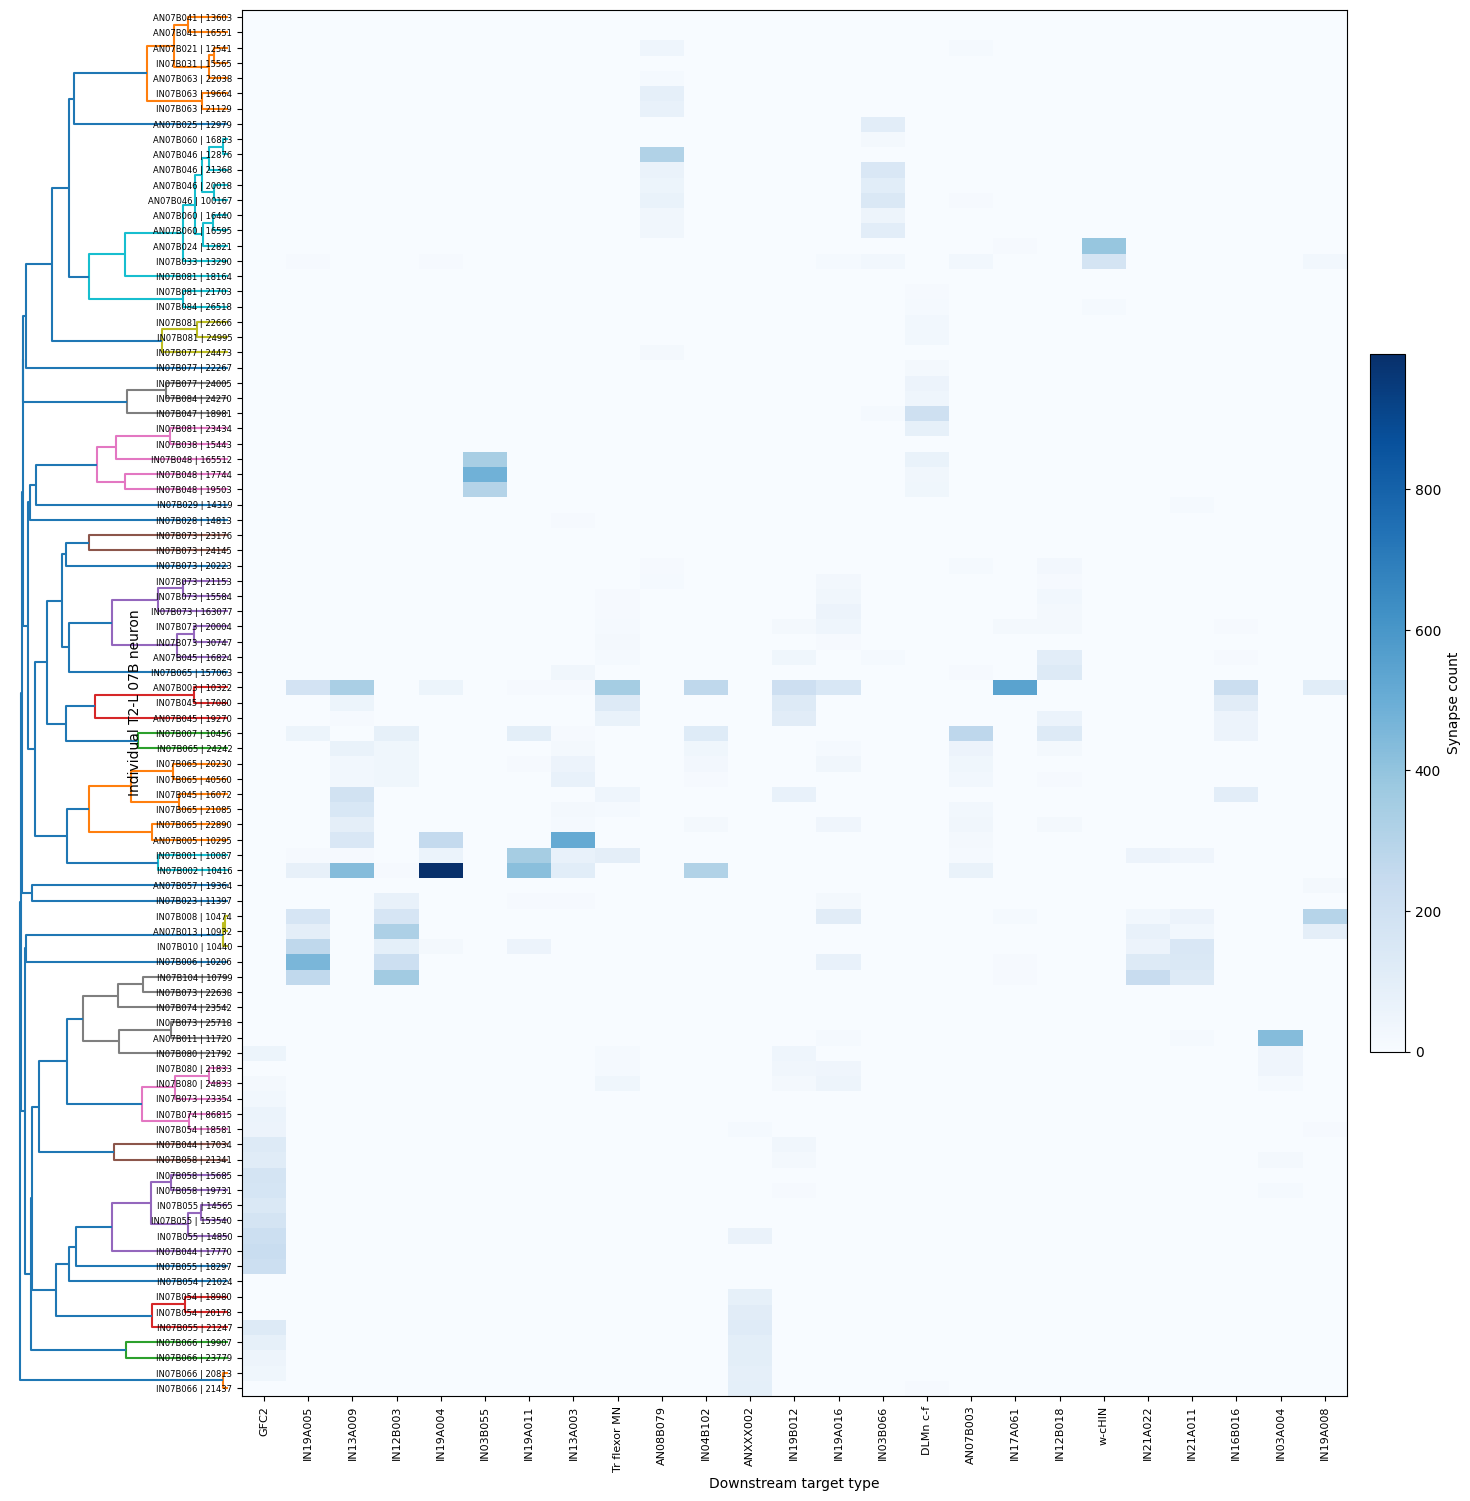

In [11]:
#counts not normalized as  plotting as fraction of that neurons total synapses


from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

print("Creating raw synapse-count heatmap with dendrogram...")

# ============================================================
# CLUSTER USING RAW SYNAPSE COUNTS
# ============================================================

distance_counts = pdist(
    matrix.values,
    metric="cosine"
)

Z_counts = linkage(
    distance_counts,
    method="average"
)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(figsize=(18, 18))

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.5, 8],
    wspace=0.02
)

# ============================================================
# DENDROGRAM
# ============================================================

ax_dendro = fig.add_subplot(gs[0])

dendro = dendrogram(
    Z_counts,
    orientation="left",
    no_labels=True,
    ax=ax_dendro
)

ax_dendro.set_xticks([])
ax_dendro.set_yticks([])

for spine in ax_dendro.spines.values():
    spine.set_visible(False)

dendro_order = dendro["leaves"]

clustered_counts = matrix.iloc[dendro_order]

# ============================================================
# SELECT STRONGEST TARGET TYPES
# ============================================================

NUMBER_OF_TARGETS = 25

top_targets_counts = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
    .head(NUMBER_OF_TARGETS)
    .index
)

plot_counts = clustered_counts[top_targets_counts]

# ============================================================
# ROW LABELS
# ============================================================

row_labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type, source_instance
    in plot_counts.index
]

# ============================================================
# HEATMAP
# ============================================================

ax_heatmap = fig.add_subplot(gs[1])

im = ax_heatmap.imshow(
    plot_counts.values,
    cmap="Blues",
    vmin=0,
    aspect="auto",
    interpolation="nearest"
)

ax_heatmap.set_xticks(range(len(plot_counts.columns)))
ax_heatmap.set_xticklabels(
    plot_counts.columns,
    rotation=90,
    fontsize=8
)

ax_heatmap.set_yticks(range(len(plot_counts.index)))
ax_heatmap.set_yticklabels(
    row_labels,
    fontsize=6
)

ax_heatmap.set_xlabel("Downstream target type")
ax_heatmap.set_ylabel("Individual T2-L 07B neuron")

# ============================================================
# COLOR BAR
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax_heatmap,
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Synapse count")

plt.tight_layout()

print("✓ Raw synapse-count heatmap complete")

plt.show()


Calculating cosine similarity...
✓ Cosine similarity matrix created
  Matrix dimensions: (91, 91)
✓ Neurons ordered by connectivity clustering
Creating cosine similarity heatmap...
✓ Cosine similarity heatmap complete


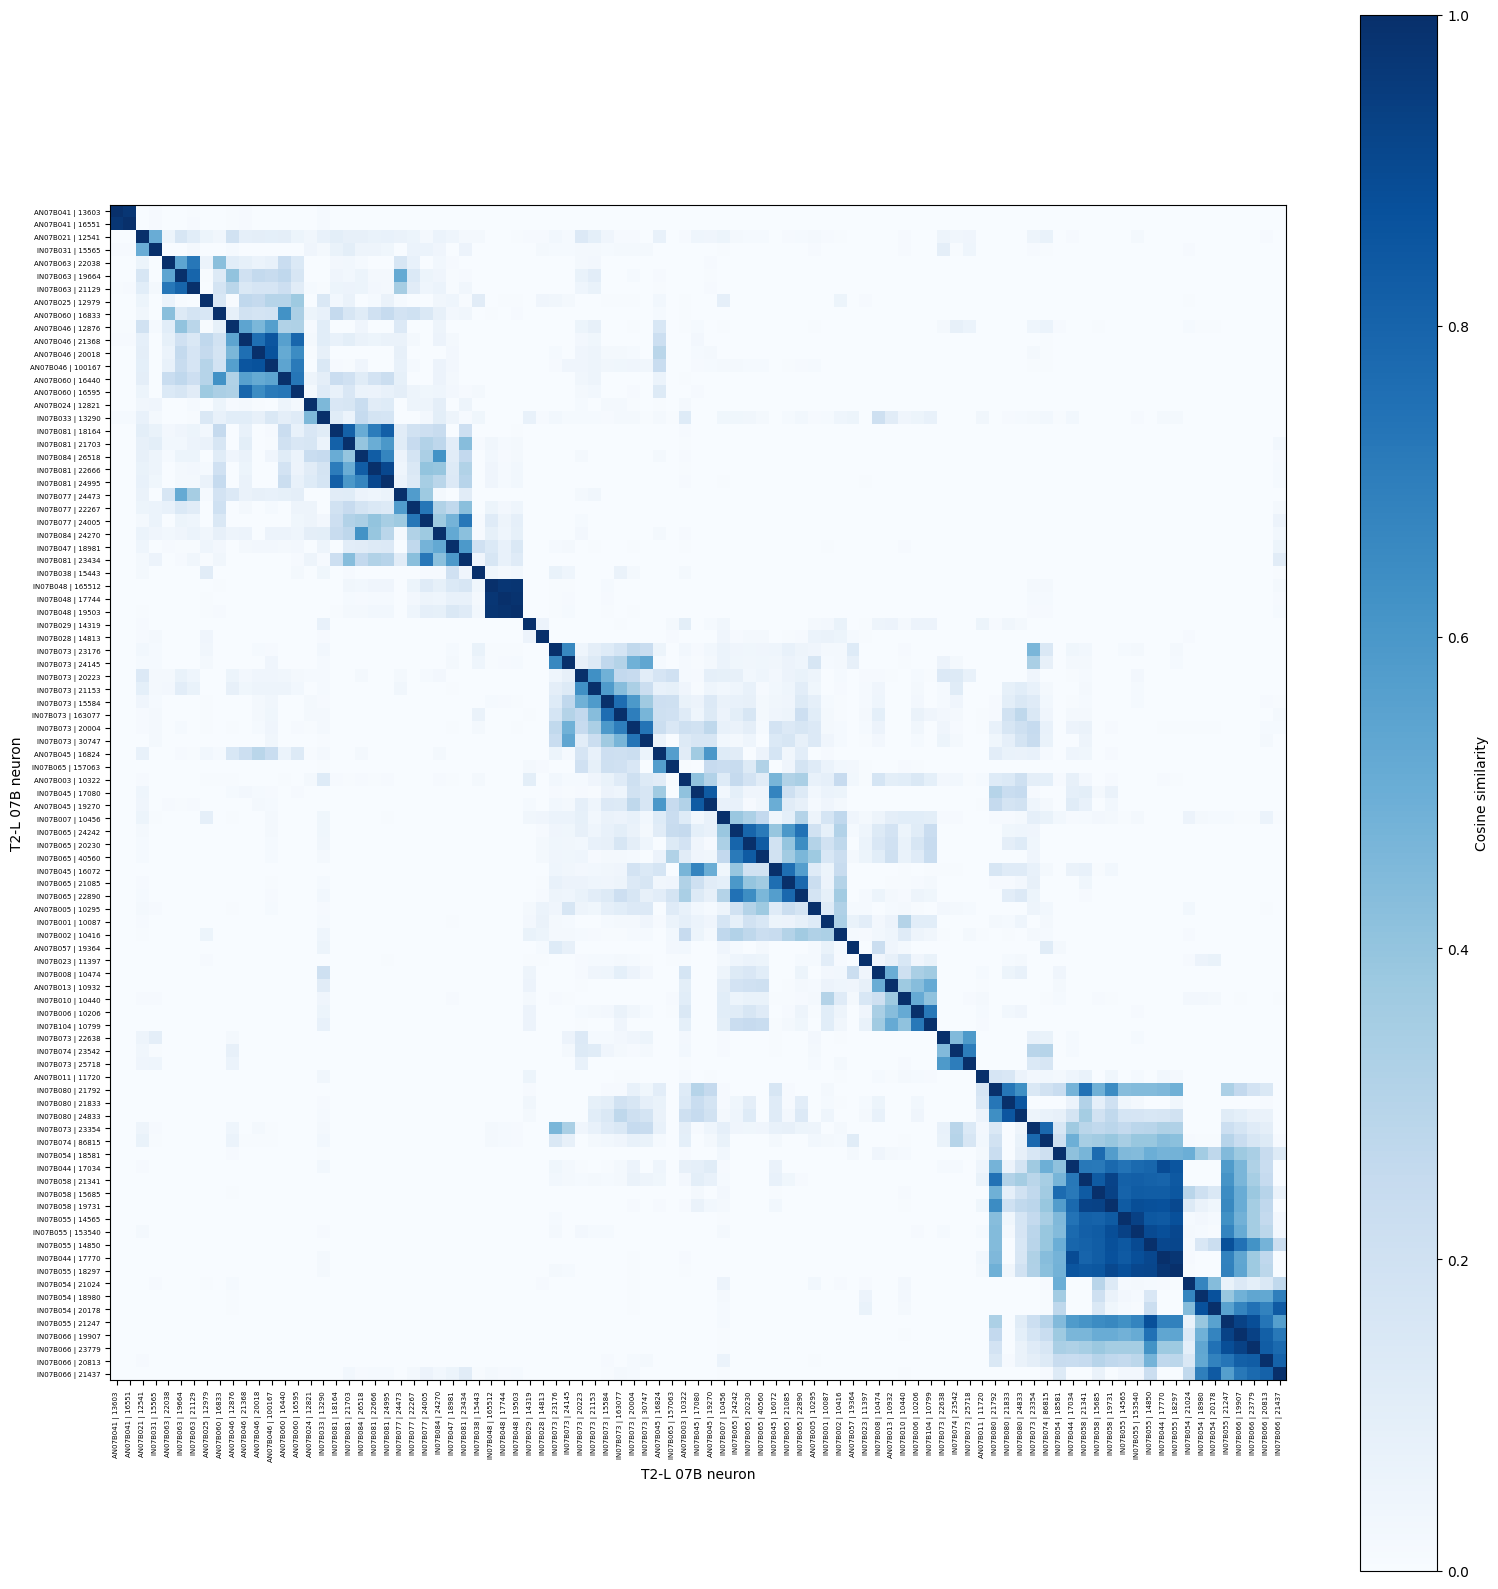

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

print("\nCalculating cosine similarity...")

# ============================================================
# CALCULATE COSINE SIMILARITY
# ============================================================

# Each row = one 07B neuron
# Each column = downstream target type
cosine_sim = cosine_similarity(normalized.values)

cosine_df = pd.DataFrame(
    cosine_sim,
    index=normalized.index,
    columns=normalized.index
)

print("✓ Cosine similarity matrix created")
print(f"  Matrix dimensions: {cosine_df.shape}")


# ============================================================
# ORDER NEURONS USING EXISTING HIERARCHICAL CLUSTERING
# ============================================================

cosine_clustered = cosine_df.iloc[row_order, row_order]

print("✓ Neurons ordered by connectivity clustering")


# ============================================================
# CREATE LABELS
# ============================================================

labels = [
    f"{source_type} | {source_id}"
    for source_id, source_type, source_instance
    in cosine_clustered.index
]


# ============================================================
# PLOT COSINE SIMILARITY HEATMAP
# ============================================================

print("Creating cosine similarity heatmap...")

fig, ax = plt.subplots(figsize=(16, 16))

im = ax.imshow(
    cosine_clustered.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="equal"
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=5
)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=5
)

ax.set_xlabel("T2-L 07B neuron")
ax.set_ylabel("T2-L 07B neuron")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()

print("✓ Cosine similarity heatmap complete")

plt.show()